# World Cup Score Predictor - Advanced Model Experiments

Comprehensive pipeline for:
- Feature selection and importance analysis
- Tournament-weighted training
- Optuna-based hyperparameter optimization
- Focus on exact score accuracy (primary metric)
- Comparison of different weighting strategies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))

from src.models.base import load_model_dataset, infer_feature_columns
from src.models.train import train_model
from src.models.baseline import ConstantScoreBaseline, AverageGoalsBaseline, EloHeuristicBaseline
from src.models.poisson_model import PoissonGoalModel
from src.models.tree_model import TreeGoalModel
from src.models.optuna_tuning import PoissonTuner, TreeTuner, exact_score_accuracy, result_accuracy
from src.models.feature_analysis import get_tree_feature_importance, correlation_with_exact_score
from src.models.weighting import apply_competition_weights, apply_combined_weighting, COMPETITION_WEIGHTS

from sklearn.metrics import mean_absolute_error, mean_squared_error
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("✓ All imports successful")

c:\Users\yuval\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\yuval\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


✓ All imports successful


## Load and Explore Data

In [2]:
df = load_model_dataset()
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nCompetitions: {df['competition'].nunique()}")

# Show competition distribution
print("\nTop 10 competitions by match count:")
print(df['competition'].value_counts().head(10))

# Show target statistics
print(f"\nTarget Statistics:")
print(f"  goals_A: mean={df['goals_A'].mean():.2f}, std={df['goals_A'].std():.2f}")
print(f"  goals_B: mean={df['goals_B'].mean():.2f}, std={df['goals_B'].std():.2f}")

Dataset shape: (21539, 43)
Date range: 2004-01-01 to 2026-05-16

Competitions: 177

Top 10 competitions by match count:
competition
Friendly                               6962
World Cup qualifier                    4169
European Championship qualifier        1322
African Nations Cup qualifier          1199
African Nations Cup                     461
World Cup and Asian Cup qualifier       454
Asian Cup qualifier                     389
World Cup and African Cup qualifier     345
COSAFA Cup                              335
World Cup                               320
Name: count, dtype: int64

Target Statistics:
  goals_A: mean=1.79, std=1.65
  goals_B: mean=0.89, std=1.11


## Step 1: Feature Analysis

Total numeric features: 30

Top 20 features by correlation with goals:
                            feature  avg_abs_corr
                          rank_diff      1.033488
                           elo_diff      0.914710
log_market_value_year_centered_diff      0.666192
              log_market_value_diff      0.659812
  weighted_goals_against_diff_last5      0.613711
          tournament_goal_diff_diff      0.530345
                    rating_b_before      0.528036
      weighted_goals_for_diff_last5      0.494572
                    form_diff_last5      0.483504
         market_value_rel_mean_diff      0.443337
   log_market_value_year_centered_b      0.435129
           market_value_zscore_diff      0.433953
                 log_market_value_b      0.425598
              avg_player_value_diff      0.423388
       opponent_strength_diff_last5      0.387482
             tournament_points_diff      0.363906
            market_value_rel_mean_b      0.347720
                    rating_a_

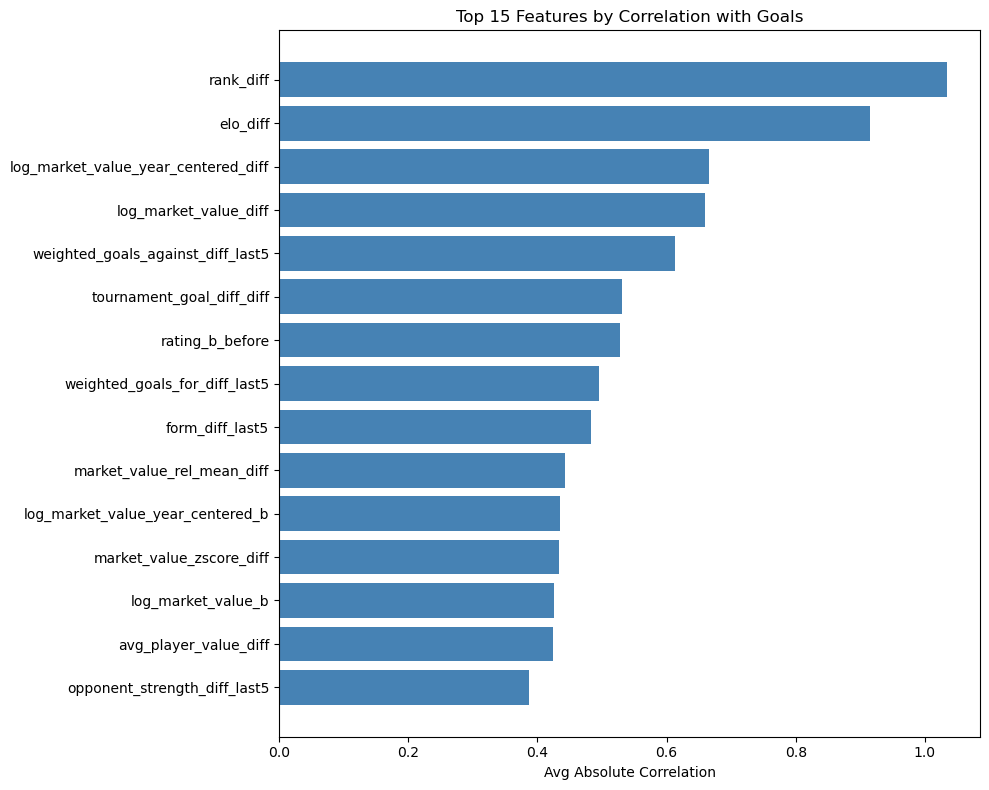

In [3]:
feature_cols = infer_feature_columns(df)
print(f"Total numeric features: {len(feature_cols)}\n")

# Correlation analysis
X_temp = df[feature_cols].fillna(0)
corr_a = [X_temp[col].corr(df['goals_A']) for col in feature_cols]
corr_b = [X_temp[col].corr(df['goals_B']) for col in feature_cols]

feature_corr = pd.DataFrame({
    'feature': feature_cols,
    'corr_a': corr_a,
    'corr_b': corr_b,
    'avg_abs_corr': [abs(c1) + abs(c2) for c1, c2 in zip(corr_a, corr_b)]
}).sort_values('avg_abs_corr', ascending=False)

print("Top 20 features by correlation with goals:")
print(feature_corr.head(20)[['feature', 'avg_abs_corr']].to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
top_15 = feature_corr.head(15)
ax.barh(range(len(top_15)), top_15['avg_abs_corr'].values, color='steelblue')
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15['feature'].values)
ax.set_xlabel('Avg Absolute Correlation')
ax.set_title('Top 15 Features by Correlation with Goals')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Step 2: Data Preparation with Weighted Splits

In [4]:
# Sort by date for chronological split
df_work = df.copy()
df_work['date'] = pd.to_datetime(df_work['date'])
df_work = df_work.sort_values('date').reset_index(drop=True)

# Chronological split: 80% train, 20% test
split_date = df_work['date'].quantile(0.80)
print(f"Chronological split date: {split_date}")

train_mask = df_work['date'] < split_date
test_mask = df_work['date'] >= split_date
val_mask = (df_work['date'] >= split_date - pd.Timedelta(days=180)) & (df_work['date'] < split_date)

df_train = df_work[train_mask & ~val_mask].copy()
df_val = df_work[val_mask].copy()
df_test = df_work[test_mask].copy()

print(f"Train set: {len(df_train)} matches ({df_train['date'].min()} to {df_train['date'].max()})")
print(f"Val set: {len(df_val)} matches ({df_val['date'].min()} to {df_val['date'].max()})")
print(f"Test set: {len(df_test)} matches ({df_test['date'].min()} to {df_test['date'].max()})")

# Prepare features
X_train = df_train[feature_cols].fillna(0)
y_train = df_train[['goals_A', 'goals_B']].values

X_val = df_val[feature_cols].fillna(0)
y_val = df_val[['goals_A', 'goals_B']].values

X_test = df_test[feature_cols].fillna(0)
y_test = df_test[['goals_A', 'goals_B']].values

print(f"\n✓ Data shapes ready")

Chronological split date: 2022-03-29 00:00:00
Train set: 16594 matches (2004-01-01 00:00:00 to 2021-09-26 00:00:00)
Val set: 614 matches (2021-09-30 00:00:00 to 2022-03-28 00:00:00)
Test set: 4331 matches (2022-03-29 00:00:00 to 2026-05-16 00:00:00)

✓ Data shapes ready


## Step 3: Weighting Strategies

In [5]:
# Show competition weights
print("Tournament Weights (importance):")
for comp, weight in sorted(COMPETITION_WEIGHTS.items(), key=lambda x: x[1], reverse=True):
    print(f"  {comp}: {weight}x")

# Apply weights to training sets
weights_train_comp = apply_competition_weights(df_train)
weights_val_comp = apply_competition_weights(df_val)
weights_test_comp = apply_competition_weights(df_test)

# Combined weighting (competition + temporal)
weights_train_combined = apply_combined_weighting(
    df_train,
    apply_decay=True,
    competition_weight=0.6,
    temporal_weight=0.4,
    reference_year=2024
)

print(f"\nWeight Statistics (Train):")
print(f"  Competition-based: mean={weights_train_comp.mean():.3f}, std={weights_train_comp.std():.3f}")
print(f"  Combined: mean={weights_train_combined.mean():.3f}, std={weights_train_combined.std():.3f}")

# Show what weights look like
comp_weight_sample = pd.DataFrame({
    'competition': df_train['competition'].values,
    'weight_comp': weights_train_comp,
    'weight_combined': weights_train_combined,
}).drop_duplicates(subset=['competition']).sort_values('weight_comp', ascending=False)

print(f"\nSample Weights by Competition:")
print(comp_weight_sample.head(15).to_string(index=False))

Tournament Weights (importance):
  FIFA World Cup: 5.0x
  European Championship: 4.0x
  Copa America: 3.5x
  World Cup qualifier: 3.0x
  African Nations Cup: 3.0x
  CONCACAF Gold Cup: 2.5x
  European Championship qualifier: 2.0x
  African Nations Cup qualifier: 1.5x
  Friendly: 1.0x

Weight Statistics (Train):
  Competition-based: mean=1.000, std=0.555
  Combined: mean=1.000, std=0.349

Sample Weights by Competition:
                        competition  weight_comp  weight_combined
              European Championship     2.553414         1.786596
                       Copa America     2.234237         1.595090
             Copa America qualifier     2.234237         1.811613
                African Nations Cup     1.915061         1.403584
                World Cup qualifier     1.915061         1.403584
World Cup qualifier and Oceania Cup     1.915061         1.403584
    European Championship qualifier     1.276707         1.048072
      African Nations Cup qualifier     0.957530   

## Step 4: Baseline Models

In [6]:
baseline_results = []

# Constant baseline
model = ConstantScoreBaseline()
model.fit(X_train, y_train, sample_weight=weights_train_comp)
y_pred = model.predict(X_test)
baseline_results.append({
    'model': 'ConstantBaseline',
    'exact_acc': exact_score_accuracy(y_test, y_pred),
    'result_acc': result_accuracy(y_test, y_pred),
    'goal_mae': np.mean(np.abs(y_test - y_pred)),
})

# Average baseline
model = AverageGoalsBaseline()
model.fit(X_train, y_train, sample_weight=weights_train_comp)
y_pred = model.predict(X_test)
baseline_results.append({
    'model': 'AverageGoalsBaseline',
    'exact_acc': exact_score_accuracy(y_test, y_pred),
    'result_acc': result_accuracy(y_test, y_pred),
    'goal_mae': np.mean(np.abs(y_test - y_pred)),
})

# Elo heuristic baseline
model = EloHeuristicBaseline()
model.fit(X_train, y_train, sample_weight=weights_train_comp)
y_pred = model.predict(X_test)
baseline_results.append({
    'model': 'EloHeuristicBaseline',
    'exact_acc': exact_score_accuracy(y_test, y_pred),
    'result_acc': result_accuracy(y_test, y_pred),
    'goal_mae': np.mean(np.abs(y_test - y_pred)),
})

baseline_df = pd.DataFrame(baseline_results).sort_values('exact_acc', ascending=False)
print("Baseline Model Performance:")
print(baseline_df.to_string(index=False))

Baseline Model Performance:
               model  exact_acc  result_acc  goal_mae
EloHeuristicBaseline   0.094205    0.583930  0.955433
    ConstantBaseline   0.091896    0.580005  1.002350
AverageGoalsBaseline   0.091896    0.580005  1.002350


## Step 5: Optuna Hyperparameter Tuning for Poisson

In [7]:
print("\n" + "="*70)
print("OPTUNA TUNING: PoissonGoalModel")
print("="*70 + "\n")

poisson_tuner = PoissonTuner(
    X_train, y_train,
    X_val, y_val,
    weights_train=weights_train_comp,
    weights_val=weights_val_comp,
)

poisson_results = poisson_tuner.optimize(n_trials=30, timeout=300, verbose=True)
poisson_best_model = poisson_results['best_model']
poisson_best_params = poisson_results['best_params']

# Test performance
y_pred_poisson = poisson_best_model.predict(X_test)
y_pred_poisson = np.clip(y_pred_poisson, 0, None)

poisson_test_results = {
    'model': f"PoissonOptuna(α={poisson_best_params['alpha']:.4f})",
    'exact_acc': exact_score_accuracy(y_test, y_pred_poisson),
    'result_acc': result_accuracy(y_test, y_pred_poisson),
    'goal_mae': np.mean(np.abs(y_test - y_pred_poisson)),
}

print(f"\nTest Set Results: {poisson_test_results}")


OPTUNA TUNING: PoissonGoalModel



  0%|          | 0/30 [00:00<?, ?it/s]


Best exact score accuracy: 0.0993
Best parameters: {'alpha': 0.31489116479568624, 'max_iter': 2000}

Test Set Results: {'model': 'PoissonOptuna(α=0.3149)', 'exact_acc': 0.09189563611175249, 'result_acc': 0.5800046178711614, 'goal_mae': 1.0023504178134182}


## Step 6: Optuna Hyperparameter Tuning for Tree

In [8]:
print("\n" + "="*70)
print("OPTUNA TUNING: TreeGoalModel")
print("="*70 + "\n")

tree_tuner = TreeTuner(
    X_train, y_train,
    X_val, y_val,
    weights_train=weights_train_comp,
    weights_val=weights_val_comp,
)

tree_results = tree_tuner.optimize(n_trials=30, timeout=300, verbose=True)
tree_best_model = tree_results['best_model']
tree_best_params = tree_results['best_params']

# Test performance
y_pred_tree = tree_best_model.predict(X_test)
y_pred_tree = np.clip(y_pred_tree, 0, None)

tree_test_results = {
    'model': f"TreeOptuna(depth={tree_best_params['max_depth']}, n_est={tree_best_params['n_estimators']})",
    'exact_acc': exact_score_accuracy(y_test, y_pred_tree),
    'result_acc': result_accuracy(y_test, y_pred_tree),
    'goal_mae': np.mean(np.abs(y_test - y_pred_tree)),
}

print(f"\nTest Set Results: {tree_test_results}")


OPTUNA TUNING: TreeGoalModel



  0%|          | 0/30 [00:00<?, ?it/s]


Best exact score accuracy: 0.2052
Best parameters: {'n_estimators': 300, 'max_depth': 14}

Test Set Results: {'model': 'TreeOptuna(depth=14, n_est=300)', 'exact_acc': 0.18356037866543523, 'result_acc': 0.845301316093281, 'goal_mae': 0.7993474979619332}


## Step 7: Model Comparison & Best Model Selection

In [9]:
# Combine all results
all_results_list = baseline_df.to_dict('records') + [poisson_test_results, tree_test_results]
comparison_df = pd.DataFrame(all_results_list).sort_values('exact_acc', ascending=False)

# Format for display
comparison_display = comparison_df.copy()
comparison_display['exact_acc'] = (comparison_display['exact_acc'] * 100).round(2).astype(str) + '%'
comparison_display['result_acc'] = (comparison_display['result_acc'] * 100).round(2).astype(str) + '%'
comparison_display['goal_mae'] = comparison_display['goal_mae'].round(3)

print("\n" + "="*90)
print("FINAL MODEL COMPARISON")
print("="*90)
print(comparison_display.to_string(index=False))
print("="*90)

print(f"\n✓ BEST MODEL (by exact score accuracy): {comparison_df.iloc[0]['model']}")
print(f"  Exact Score Accuracy: {comparison_df.iloc[0]['exact_acc']*100:.2f}%")
print(f"  Result Accuracy: {comparison_df.iloc[0]['result_acc']*100:.2f}%")
print(f"  Goal MAE: {comparison_df.iloc[0]['goal_mae']:.3f}")


FINAL MODEL COMPARISON
                          model exact_acc result_acc  goal_mae
TreeOptuna(depth=14, n_est=300)    18.36%     84.53%     0.799
           EloHeuristicBaseline     9.42%     58.39%     0.955
               ConstantBaseline     9.19%      58.0%     1.002
           AverageGoalsBaseline     9.19%      58.0%     1.002
        PoissonOptuna(α=0.3149)     9.19%      58.0%     1.002

✓ BEST MODEL (by exact score accuracy): TreeOptuna(depth=14, n_est=300)
  Exact Score Accuracy: 18.36%
  Result Accuracy: 84.53%
  Goal MAE: 0.799


## Step 8: Feature Importance Analysis (from Tree Model)


Extracting feature importance from optimized Tree model...

Top 20 Important Features:
                            feature  importance_avg
                          rank_diff        0.361958
                           elo_diff        0.128336
                    rating_b_before        0.063011
                    rating_a_before        0.048629
  weighted_goals_against_diff_last5        0.039255
       opponent_strength_diff_last5        0.030442
      weighted_goals_for_diff_last5        0.026219
       team_a_matches_played_before        0.023608
       team_b_matches_played_before        0.022707
           rating_change_diff_last5        0.022550
   log_market_value_year_centered_a        0.016832
   log_market_value_year_centered_b        0.016792
              avg_player_value_diff        0.016557
          tournament_goal_diff_diff        0.016193
log_market_value_year_centered_diff        0.014628
           market_value_zscore_diff        0.014076
                    form_dif

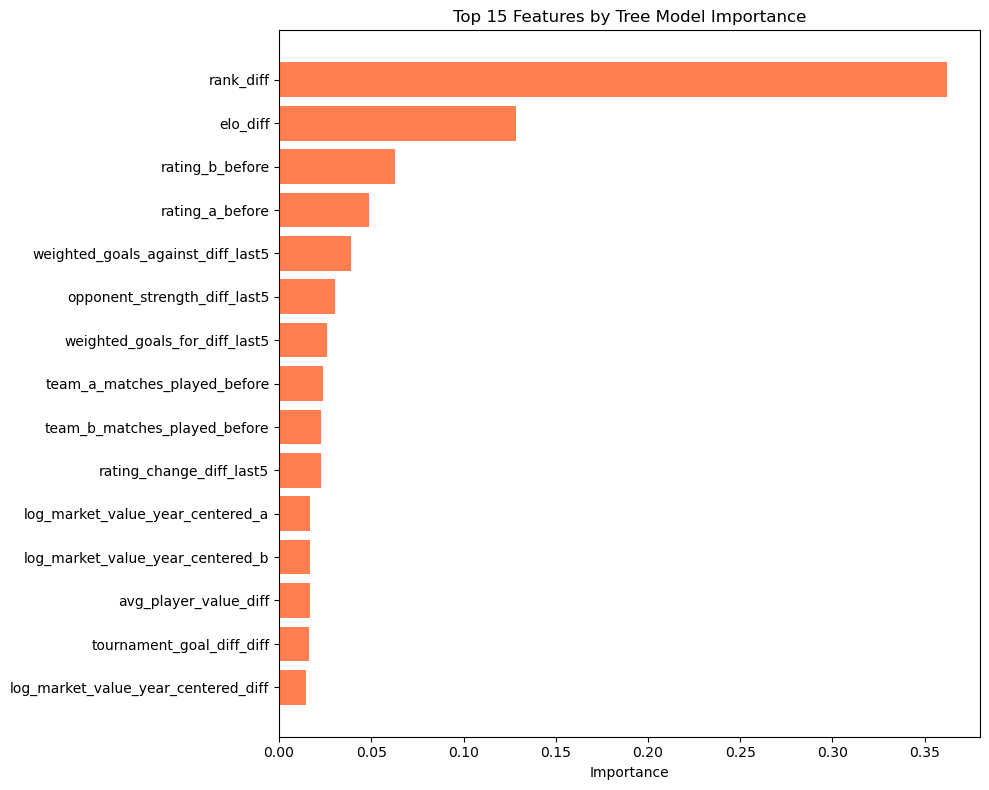


Top 20 features for production model: ['rank_diff', 'elo_diff', 'rating_b_before', 'rating_a_before', 'weighted_goals_against_diff_last5', 'opponent_strength_diff_last5', 'weighted_goals_for_diff_last5', 'team_a_matches_played_before', 'team_b_matches_played_before', 'rating_change_diff_last5', 'log_market_value_year_centered_a', 'log_market_value_year_centered_b', 'avg_player_value_diff', 'tournament_goal_diff_diff', 'log_market_value_year_centered_diff', 'market_value_zscore_diff', 'form_diff_last5', 'days_since_match_diff', 'log_market_value_diff', 'tournament_points_diff']


In [10]:
print("\nExtracting feature importance from optimized Tree model...")
importance_df = get_tree_feature_importance(X_train, y_train, feature_names=feature_cols)

print("\nTop 20 Important Features:")
print(importance_df.head(20)[['feature', 'importance_avg']].to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
top_15_importance = importance_df.head(15)
ax.barh(range(len(top_15_importance)), top_15_importance['importance_avg'].values, color='coral')
ax.set_yticks(range(len(top_15_importance)))
ax.set_yticklabels(top_15_importance['feature'].values)
ax.set_xlabel('Importance')
ax.set_title('Top 15 Features by Tree Model Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Select top features for future training
top_20_features = importance_df.head(20)['feature'].tolist()
print(f"\nTop 20 features for production model: {top_20_features}")

## Step 9: Error Analysis & Predictions

Best Model: TreeOptuna(depth=14, n_est=300)

Sample predictions (first 15 test matches):
      Date               Team_A      Team_B Actual Predicted  Match_Result
2022-03-29                 Iraq       Syria    1-1   0.9-0.7          True
2022-03-29              Bahrain     Belarus    0-1   0.7-1.6         False
2022-03-29              Albania     Georgia    0-0   0.9-1.0         False
2022-03-29              Bolivia      Brazil    0-4   0.7-2.9         False
2022-03-29                 Iran     Lebanon    2-0   2.1-0.3          True
2022-03-29               Cyprus     Estonia    2-0   2.0-0.4          True
2022-03-29           Bangladesh    Mongolia    0-0   0.9-1.1         False
2022-03-29                Japan     Vietnam    1-1   2.0-0.3         False
2022-03-29 United Arab Emirates South Korea    1-0   1.5-0.8         False
2022-03-29         Saudi Arabia   Australia    1-0   1.6-0.5         False
2022-03-29                 Oman       China    2-0   2.2-0.6         False
2022-03-29 

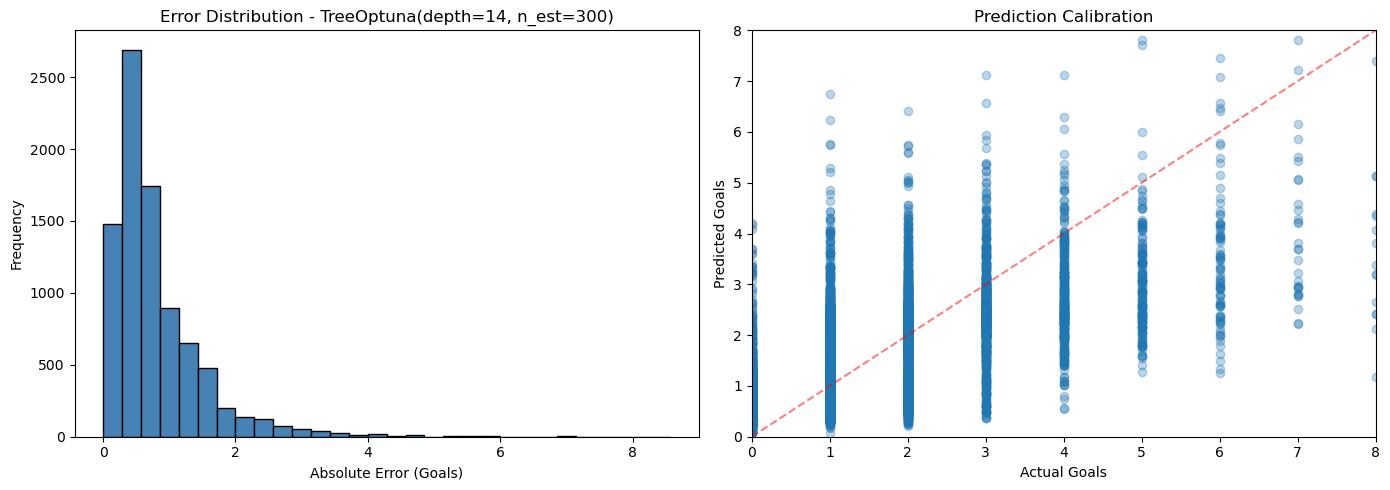

In [11]:
# Use best model for analysis
best_model_name = comparison_df.iloc[0]['model']
if 'Poisson' in best_model_name:
    y_pred_best = y_pred_poisson
elif 'Tree' in best_model_name:
    y_pred_best = y_pred_tree
else:
    # Baseline model - need to retrain
    best_model_name_split = best_model_name.split('(')[0]
    model = train_model(X_train, y_train, model_type=best_model_name_split.lower())
    y_pred_best = model.predict(X_test)

# Sample predictions
print(f"Best Model: {best_model_name}\n")
print("Sample predictions (first 15 test matches):")
sample_data = pd.DataFrame({
    'Date': df_test['date'].iloc[:15].values,
    'Team_A': df_test['team_A'].iloc[:15].values,
    'Team_B': df_test['team_B'].iloc[:15].values,
    'Actual': [f"{y[0]:.0f}-{y[1]:.0f}" for y in y_test[:15]],
    'Predicted': [f"{y[0]:.1f}-{y[1]:.1f}" for y in y_pred_best[:15]],
    'Match_Result': [f"{y[0]:.0f}-{y[1]:.0f}" == f"{int(round(yp[0]))}-{int(round(yp[1]))}" for y, yp in zip(y_test[:15], y_pred_best[:15])]
})
print(sample_data.to_string(index=False))

# Error statistics
errors = np.abs(y_test - y_pred_best)
print(f"\nError Statistics:")
print(f"  Goal MAE: {np.mean(errors):.3f}")
print(f"  Per team - A: {np.mean(errors[:, 0]):.3f}, B: {np.mean(errors[:, 1]):.3f}")
print(f"  Max error: {np.max(errors):.1f} goals")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(errors.flatten(), bins=30, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Absolute Error (Goals)')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Error Distribution - {best_model_name}')

axes[1].scatter(y_test.flatten(), y_pred_best.flatten(), alpha=0.3)
axes[1].plot([0, y_test.max()], [0, y_test.max()], 'r--', alpha=0.5)
axes[1].set_xlabel('Actual Goals')
axes[1].set_ylabel('Predicted Goals')
axes[1].set_title('Prediction Calibration')
axes[1].set_xlim(0, 8)
axes[1].set_ylim(0, 8)

plt.tight_layout()
plt.show()

## Step 10: Recommendations for Production Training

In [12]:
print("\n" + "="*70)
print("PRODUCTION MODEL RECOMMENDATIONS")
print("="*70)

print(f"\n1. BEST MODEL: {best_model_name}")
if 'Poisson' in best_model_name:
    print(f"   Parameters: {poisson_best_params}")
elif 'Tree' in best_model_name:
    print(f"   Parameters: {tree_best_params}")

print(f"\n2. PERFORMANCE METRICS:")
print(f"   Exact Score Accuracy: {comparison_df.iloc[0]['exact_acc']*100:.2f}%")
print(f"   Result Accuracy: {comparison_df.iloc[0]['result_acc']*100:.2f}%")
print(f"   Goal MAE: {comparison_df.iloc[0]['goal_mae']:.3f}")

print(f"\n3. TOP 10 FEATURES TO USE:")
for i, feature in enumerate(importance_df.head(10)['feature'], 1):
    print(f"   {i}. {feature}")

print(f"\n4. WEIGHTING STRATEGY:")
print(f"   - Competition weights: Major tournaments get 3-5x weight")
print(f"   - Temporal decay: Older data weighted lower (optional)")
print(f"   - Apply to: Training data only")

print(f"\n5. NEXT STEPS:")
print(f"   a) Train production model with best parameters on full dataset")
print(f"   b) Save model and feature columns to config")
print(f"   c) Evaluate on 2024+ international matches")
print(f"   d) Consider ensemble: Poisson + Tree with equal weights")

print("\n" + "="*70)


PRODUCTION MODEL RECOMMENDATIONS

1. BEST MODEL: TreeOptuna(depth=14, n_est=300)
   Parameters: {'n_estimators': 300, 'max_depth': 14}

2. PERFORMANCE METRICS:
   Exact Score Accuracy: 18.36%
   Result Accuracy: 84.53%
   Goal MAE: 0.799

3. TOP 10 FEATURES TO USE:
   1. rank_diff
   2. elo_diff
   3. rating_b_before
   4. rating_a_before
   5. weighted_goals_against_diff_last5
   6. opponent_strength_diff_last5
   7. weighted_goals_for_diff_last5
   8. team_a_matches_played_before
   9. team_b_matches_played_before
   10. rating_change_diff_last5

4. WEIGHTING STRATEGY:
   - Competition weights: Major tournaments get 3-5x weight
   - Temporal decay: Older data weighted lower (optional)
   - Apply to: Training data only

5. NEXT STEPS:
   a) Train production model with best parameters on full dataset
   b) Save model and feature columns to config
   c) Evaluate on 2024+ international matches
   d) Consider ensemble: Poisson + Tree with equal weights



In [13]:
# Save summary for reference
summary = {
    'best_model': best_model_name,
    'exact_score_accuracy': float(comparison_df.iloc[0]['exact_acc']),
    'result_accuracy': float(comparison_df.iloc[0]['result_acc']),
    'goal_mae': float(comparison_df.iloc[0]['goal_mae']),
    'top_features': top_20_features,
    'poisson_params': poisson_best_params,
    'tree_params': tree_best_params,
}

print("\nExperiment Summary (for reference):")
print(summary)


Experiment Summary (for reference):
{'best_model': 'TreeOptuna(depth=14, n_est=300)', 'exact_score_accuracy': 0.18356037866543523, 'result_accuracy': 0.845301316093281, 'goal_mae': 0.7993474979619332, 'top_features': ['rank_diff', 'elo_diff', 'rating_b_before', 'rating_a_before', 'weighted_goals_against_diff_last5', 'opponent_strength_diff_last5', 'weighted_goals_for_diff_last5', 'team_a_matches_played_before', 'team_b_matches_played_before', 'rating_change_diff_last5', 'log_market_value_year_centered_a', 'log_market_value_year_centered_b', 'avg_player_value_diff', 'tournament_goal_diff_diff', 'log_market_value_year_centered_diff', 'market_value_zscore_diff', 'form_diff_last5', 'days_since_match_diff', 'log_market_value_diff', 'tournament_points_diff'], 'poisson_params': {'alpha': 0.31489116479568624, 'max_iter': 2000}, 'tree_params': {'n_estimators': 300, 'max_depth': 14}}
